In [ ]:
#Import Libraries
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
import torch
import cv2
from PIL import Image
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from torch.utils.data import Dataset
from torch.utils.data import random_split, DataLoader
from torch.utils.data import DataLoader, random_split, ConcatDataset
import timm
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from collections import Counter
import torch.nn.functional as F
import random
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm



In [ ]:
# # Load pretrained CNN model (same setup as your model)
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# cnn = timm.create_model('convnext_base', pretrained=True, num_classes=0)
# cnn.stem[0] = torch.nn.Conv2d(1, 128, kernel_size=(4, 4), stride=(4, 4))
# cnn.to(device)
# cnn.eval()

# # CLAHE preprocessing
# clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))

# def preprocess(pil_img):
#     img = np.array(pil_img.convert("L"))
#     clahe_img = clahe.apply(img)
#     clahe_img = clahe_img.astype(np.float32) / 255.0
#     clahe_img = torch.tensor(clahe_img).unsqueeze(0).unsqueeze(0)
#     return clahe_img

# # The extraction function
# def process_dataset(root_folder, output_folder):
#     os.makedirs(output_folder, exist_ok=True)
#     folders = [f for f in os.listdir(root_folder) if os.path.isdir(os.path.join(root_folder, f))]

#     for folder in tqdm(folders, desc=f"Processing {root_folder}"):
#         folder_path = os.path.join(root_folder, folder)
#         out_path = os.path.join(output_folder, folder)
#         os.makedirs(out_path, exist_ok=True)

#         for week_file in ["week-2.csv", "week-3.csv", "week-4.csv"]:
#             csv_path = os.path.join(folder_path, week_file)
#             if not os.path.exists(csv_path):
#                 continue

#             df = pd.read_csv(csv_path)
#             if df.empty or "Image_Path" not in df.columns:
#                 continue

#             try:
#                 img_path = df.loc[0, "Image_Path"]
#                 pil_img = Image.open(img_path)
#                 img_tensor = preprocess(pil_img).to(device)

#                 with torch.no_grad():
#                     features = cnn(img_tensor).cpu().numpy().flatten()

#                 # Drop Image_Path column and add CNN features
#                 df = df.drop(columns=["Image_Path"])
#                 for i, feat in enumerate(features):
#                     df[f"cnn_feat_{i+1}"] = feat

#                 df.to_csv(os.path.join(out_path, week_file), index=False)

#             except Exception as e:
#                 print(f"Error processing {img_path}: {e}")

# # Define all folders for both rows

# # Row 3
# train_root_row3 = "/content/drive/MyDrive/Thesis/POM-IMG/train_row3_SEF"
# test_root_row3 = "/content/drive/MyDrive/Thesis/POM-IMG/test_row3_SEF"
# train_out_row3 = "/content/drive/MyDrive/Thesis/POM-IMG/train_row3_SEF_CNN"
# test_out_row3 = "/content/drive/MyDrive/Thesis/POM-IMG/test_row3_SEF_CNN"

# # Row 4
# train_root_row4 = "/content/drive/MyDrive/Thesis/POM-IMG/train_row4_SEF"
# test_root_row4 = "/content/drive/MyDrive/Thesis/POM-IMG/test_row4_SEF"
# train_out_row4 = "/content/drive/MyDrive/Thesis/POM-IMG/train_row4_SEF_CNN"
# test_out_row4 = "/content/drive/MyDrive/Thesis/POM-IMG/test_row4_SEF_CNN"

# # Run full extraction on both rows
# process_dataset(train_root_row3, train_out_row3)
# process_dataset(test_root_row3, test_out_row3)

# process_dataset(train_root_row4, train_out_row4)
# process_dataset(test_root_row4, test_out_row4)


In [ ]:
# # Paths
# train_row3_dir = "/content/drive/MyDrive/Thesis/POM-IMG/train_row3_SEF_CNN"
# train_row4_dir = "/content/drive/MyDrive/Thesis/POM-IMG/train_row4_SEF_CNN"
# test_row3_dir  = "/content/drive/MyDrive/Thesis/POM-IMG/test_row3_SEF_CNN"
# test_row4_dir  = "/content/drive/MyDrive/Thesis/POM-IMG/test_row4_SEF_CNN"

# train_out_row3 = "/content/drive/MyDrive/Thesis/POM-IMG/train_row3_SEF_LDA_CNN2"
# train_out_row4 = "/content/drive/MyDrive/Thesis/POM-IMG/train_row4_SEF_LDA_CNN2"
# test_out_row3  = "/content/drive/MyDrive/Thesis/POM-IMG/test_row3_SEF_LDA_CNN2"
# test_out_row4  = "/content/drive/MyDrive/Thesis/POM-IMG/test_row4_SEF_LDA_CNN2"

# # Load helper
# def load_metadata(root_dir):
#     features, labels, source = [], [], []
#     folders = sorted(os.listdir(root_dir))
#     for folder in folders:
#         folder_path = os.path.join(root_dir, folder)
#         for week_file in ["week-2.csv", "week-3.csv", "week-4.csv"]:
#             file_path = os.path.join(folder_path, week_file)
#             if not os.path.exists(file_path):
#                 continue
#             df = pd.read_csv(file_path)

#             # Drop Irrigation, Week, and non-feature columns
#             df = df.drop(columns=[col for col in df.columns if "Irrigation" in col or "Image_Path" in col or "Image_ID" in col or "Week" in col], errors="ignore")

#             # Store Label and remove it from features
#             label = df["Label"].iloc[0]
#             label = 2 if label == 3 else label
#             labels.append(label)
#             df = df.drop(columns=["Label"], errors="ignore")

#             features.append(df.values[0])
#             source.append((folder, week_file))
#     return np.array(features), np.array(labels), source

# # Load only train data for fitting LDA
# X_train3, y_train3, src_train3 = load_metadata(train_row3_dir)
# X_train4, y_train4, src_train4 = load_metadata(train_row4_dir)

# X_train = np.concatenate([X_train3, X_train4])
# y_train = np.concatenate([y_train3, y_train4])
# src_train = src_train3 + src_train4

# # Fit scaler + LDA only on train set
# scaler = StandardScaler().fit(X_train)
# X_train_scaled = scaler.transform(X_train)

# lda = LDA(n_components=2)
# X_train_lda = lda.fit_transform(X_train_scaled, y_train)

# # Now apply on test sets (transform only, no fit)
# X_test3, y_test3, src_test3 = load_metadata(test_row3_dir)
# X_test4, y_test4, src_test4 = load_metadata(test_row4_dir)

# X_test = np.concatenate([X_test3, X_test4])
# y_test = np.concatenate([y_test3, y_test4])
# src_test = src_test3 + src_test4

# X_test_scaled = scaler.transform(X_test)
# X_test_lda = lda.transform(X_test_scaled)

# # Save helper function
# def save_transformed(root_in, root_out, source_list, lda_values):
#     os.makedirs(root_out, exist_ok=True)
#     for i, (folder, week_file) in enumerate(source_list):
#         input_csv = os.path.join(root_in, folder, week_file)
#         df = pd.read_csv(input_csv)

#         # Keep only Label, Image_Path, Week
#         keep_cols = df.filter(regex="Label|Week|Image_Path")
#         keep_cols = keep_cols.drop(columns=["Irrigation"], errors="ignore")

#         # Add LDA features
#         df_lda = pd.DataFrame(lda_values[i].reshape(1, -1), columns=["LD1", "LD2"])
#         final_df = pd.concat([keep_cols.reset_index(drop=True), df_lda], axis=1)

#         out_folder = os.path.join(root_out, folder)
#         os.makedirs(out_folder, exist_ok=True)
#         out_path = os.path.join(out_folder, week_file)
#         final_df.to_csv(out_path, index=False)

# # Save train + test with LDA features
# save_transformed(train_row3_dir, train_out_row3, src_train3, X_train_lda[:len(src_train3)])
# save_transformed(train_row4_dir, train_out_row4, src_train4, X_train_lda[len(src_train3):])
# save_transformed(test_row3_dir, test_out_row3, src_test3, X_test_lda[:len(src_test3)])
# save_transformed(test_row4_dir, test_out_row4, src_test4, X_test_lda[len(src_test4):])

In [ ]:
class MetadataTripletDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = root_dir
        self.samples = [os.path.join(root_dir, f) for f in os.listdir(root_dir)
                        if os.path.isdir(os.path.join(root_dir, f))]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        folder_path = self.samples[idx]
        weeks = ["week-2.csv", "week-3.csv", "week-4.csv"]

        metadata_triplet = []
        label = None

        for i, week_file in enumerate(weeks):
            week_path = os.path.join(folder_path, week_file)
            df = pd.read_csv(week_path)

            # Extract LD1, LD2 (LDA applied after CNN features) + Week index
            meta = df[["LD1", "LD2"]].iloc[0].values.astype(np.float32)
            week_index = float(df["Week"].values[0][-1]) if "Week" in df.columns else (i + 2)
            meta = np.append(meta, week_index)  # Now 3 features: LD1, LD2, Week
            metadata_triplet.append(meta)

            # Get label from week-4 only
            if week_file == "week-4.csv":
                label = int(df.iloc[0]["Label"])
                if label == 3:
                    label = 2

        metadata_tensor = torch.tensor(metadata_triplet, dtype=torch.float32)  # (3, 3)
        label_tensor = torch.tensor(label, dtype=torch.long)
        return metadata_tensor, label_tensor


In [ ]:
# No transforms needed since we only load metadata
train_row3_dir = "/content/drive/MyDrive/Thesis/POM-IMG/train_row3_SEF_LDA_CNN2"
test_row3_dir = "/content/drive/MyDrive/Thesis/POM-IMG/test_row3_SEF_LDA_CNN2"

# Use the new metadata-only Dataset
full_train_dataset3 = MetadataTripletDataset(train_row3_dir)
test_row3_dataset = MetadataTripletDataset(test_row3_dir)

# Train/Val Split
train_size = int(0.8 * len(full_train_dataset3))
val_size = len(full_train_dataset3) - train_size
train_row3_dataset, val_row3_dataset = random_split(full_train_dataset3, [train_size, val_size])

# DataLoaders
train_loader3 = DataLoader(train_row3_dataset, batch_size=16, shuffle=True)
val_loader3 = DataLoader(val_row3_dataset, batch_size=16, shuffle=True)
test_loader3 = DataLoader(test_row3_dataset, batch_size=16, shuffle=False)

print(" Row 3 loaders ready!")
print(f"Train samples: {len(train_row3_dataset)} | Val samples: {len(val_row3_dataset)} | Test samples: {len(test_row3_dataset)}")
print(f"Train size: {len(train_row3_dataset)} | Batch size: {train_loader3.batch_size}")
print(f"Number of batches: {len(train_loader3)}")


 Row 3 loaders ready!
Train samples: 980 | Val samples: 245 | Test samples: 321
Train size: 980 | Batch size: 16
Number of batches: 62


In [ ]:
# No transforms needed since we only load metadata
train_row4_dir = "/content/drive/MyDrive/Thesis/POM-IMG/train_row4_SEF_LDA_CNN2"
test_row4_dir = "/content/drive/MyDrive/Thesis/POM-IMG/test_row4_SEF_LDA_CNN2"

# Use the new metadata-only Dataset
full_train_dataset4 = MetadataTripletDataset(train_row4_dir)
test_row4_dataset = MetadataTripletDataset(test_row4_dir)

# Train/Val Split
train_size = int(0.8 * len(full_train_dataset4))
val_size = len(full_train_dataset4) - train_size
train_row4_dataset, val_row4_dataset = random_split(full_train_dataset4, [train_size, val_size])

# DataLoaders
train_loader4 = DataLoader(train_row4_dataset, batch_size=16, shuffle=True)
val_loader4 = DataLoader(val_row4_dataset, batch_size=16, shuffle=True)
test_loader4 = DataLoader(test_row4_dataset, batch_size=16, shuffle=False)

print(" Row 4 loaders ready!")
print(f"Train samples: {len(train_row4_dataset)} | Val samples: {len(val_row4_dataset)} | Test samples: {len(test_row4_dataset)}")
print(f"Train size: {len(train_row4_dataset)} | Batch size: {train_loader4.batch_size}")
print(f"Number of batches: {len(train_loader4)}")


 Row 4 loaders ready!
Train samples: 980 | Val samples: 245 | Test samples: 321
Train size: 980 | Batch size: 16
Number of batches: 62


In [ ]:
# Directories
train_row3_dir = "/content/drive/MyDrive/Thesis/POM-IMG/train_row3_SEF_LDA_CNN2"
train_row4_dir = "/content/drive/MyDrive/Thesis/POM-IMG/train_row4_SEF_LDA_CNN2"
test_row3_dir  = "/content/drive/MyDrive/Thesis/POM-IMG/test_row3_SEF_LDA_CNN2"
test_row4_dir  = "/content/drive/MyDrive/Thesis/POM-IMG/test_row4_SEF_LDA_CNN2"

# Load datasets
train_dataset3 = MetadataTripletDataset(train_row3_dir)
train_dataset4 = MetadataTripletDataset(train_row4_dir)
test_dataset3  = MetadataTripletDataset(test_row3_dir)
test_dataset4  = MetadataTripletDataset(test_row4_dir)

# Merge Row 3 + Row 4
combined_train_dataset = ConcatDataset([train_dataset3, train_dataset4])
combined_test_dataset  = ConcatDataset([test_dataset3, test_dataset4])

# Split train/val
train_size = int(0.8 * len(combined_train_dataset))
val_size = len(combined_train_dataset) - train_size
train_dataset5, val_dataset5 = random_split(combined_train_dataset, [train_size, val_size])

# Create loaders
train_loader5 = DataLoader(train_dataset5, batch_size=16, shuffle=True)
val_loader5   = DataLoader(val_dataset5, batch_size=16, shuffle=True)
test_loader5  = DataLoader(combined_test_dataset, batch_size=16, shuffle=False)

print("Metadata DataLoaders ready!")
print(f"Train: {len(train_dataset5)} | Val: {len(val_dataset5)} | Test: {len(combined_test_dataset)}")


Metadata DataLoaders ready!
Train: 1960 | Val: 490 | Test: 642


In [ ]:
# Attention Block
class AttentionBlock(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_out):
        # lstm_out: (B, T, H)
        attn_weights = self.attn(lstm_out)         # (B, T, 1)
        attn_weights = torch.softmax(attn_weights, dim=1)  # Normalize across time
        context = (lstm_out * attn_weights).sum(dim=1)     # Weighted sum: (B, H)
        return context

In [ ]:
# pure LSTM + Attention for metadata only
class PomRowModel(nn.Module):
    def __init__(self, num_metadata_features, hidden_dim=128, lstm_layers=3, num_classes=3):
        super().__init__()

        # LSTM for metadata sequence
        self.lstm = nn.LSTM(
            input_size=num_metadata_features,
            hidden_size=hidden_dim,
            num_layers=lstm_layers,
            batch_first=True
        )

        # Attention for LSTM output
        self.meta_attention = AttentionBlock(hidden_dim)

        # Final fully connected head
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes)
        )

    def forward(self, meta):
        # meta: (B, 3, D)
        lstm_out, _ = self.lstm(meta)         # (B, 3, H)
        meta_attn = self.meta_attention(lstm_out)  # (B, H)
        return self.fc(meta_attn)

In [ ]:
# Reproducibility
GPU = 0
SEED = 2023

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
os.environ['PYTHONHASHSEED'] = str(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device(f"cuda:{GPU}" if torch.cuda.is_available() else "cpu")

# Focal Loss (no change)
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, weight=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.weight = weight

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, weight=self.weight, reduction='none')
        probs = F.softmax(logits, dim=1)
        targets_one_hot = F.one_hot(targets, num_classes=logits.size(1)).float()
        pt = (probs * targets_one_hot).sum(dim=1)
        focal_weight = self.alpha * (1 - pt) ** self.gamma
        loss = focal_weight * ce_loss
        return loss.mean()

# Class weights (same)
def compute_class_weights(dataloader, num_classes, device):
    all_labels = []
    for metadata, labels in dataloader:  # <-- no images here
        all_labels.extend(labels.tolist())

    label_counts = Counter(all_labels)
    total = sum(label_counts.values())
    weights = []
    for i in range(num_classes):
        class_count = label_counts.get(i, 1)
        weight = total / (num_classes * class_count)
        weights.append(weight)

    weights = np.array(weights)
    weights = weights / np.mean(weights)
    return torch.tensor(weights, dtype=torch.float32).to(device)

# Validation loop (simpler)
def validate(model, val_loader, criterion, device):
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for metadata, labels in val_loader:
            metadata = metadata.to(device)
            labels = labels.to(device)

            outputs = model(metadata)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    return val_loss / len(val_loader)

# Training loop
def train_model(model, dataloader, val_loader, num_epochs=10, lr=0.0003, num_classes=3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    class_weights = compute_class_weights(dataloader, num_classes, device)
    print(f"Normalized Class Weights: {class_weights.tolist()}")

    criterion = FocalLoss(alpha=1.0, gamma=2.0, weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, verbose=True)

    best_val_loss = float('inf')
    best_model_weights = None

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        print(f"\nEpoch {epoch+1}/{num_epochs}")

        for i, (metadata, labels) in enumerate(dataloader):
            metadata = metadata.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(metadata)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(dataloader)
        print(f"Epoch {epoch+1} Avg Train Loss: {avg_train_loss:.4f}")

        val_loss = validate(model, val_loader, criterion, device)
        print(f"Validation Loss: {val_loss:.4f}")
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_weights = model.state_dict()
            print(f"New best model saved (val_loss = {val_loss:.4f})")

    if best_model_weights is not None:
        model.load_state_dict(best_model_weights)
        print("Loaded best model weights from memory!")

    print("Training complete!")
    return model


In [ ]:
# Set number of metadata features
num_metadata_features = 3 # Set based on your dataset

# Initialize model
model = PomRowModel(num_metadata_features=num_metadata_features)

# Train the model
train_model(model, train_loader5, val_loader5, num_epochs=30, lr=0.001)


<ipython-input-1-1288907277>:39: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  metadata_tensor = torch.tensor(metadata_triplet, dtype=torch.float32)  # (3, 3)


Normalized Class Weights: [0.6524050831794739, 0.7796599268913269, 1.5679349899291992]

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1 Avg Train Loss: 0.1209
Validation Loss: 0.0581
New best model saved (val_loss = 0.0581)

Epoch 2/30
Epoch 2 Avg Train Loss: 0.0154
Validation Loss: 0.0072
New best model saved (val_loss = 0.0072)

Epoch 3/30
Epoch 3 Avg Train Loss: 0.0042
Validation Loss: 0.0020
New best model saved (val_loss = 0.0020)

Epoch 4/30
Epoch 4 Avg Train Loss: 0.0032
Validation Loss: 0.0009
New best model saved (val_loss = 0.0009)

Epoch 5/30
Epoch 5 Avg Train Loss: 0.0019
Validation Loss: 0.0010

Epoch 6/30
Epoch 6 Avg Train Loss: 0.0016
Validation Loss: 0.0029

Epoch 7/30
Epoch 7 Avg Train Loss: 0.0038
Validation Loss: 0.0005
New best model saved (val_loss = 0.0005)

Epoch 8/30
Epoch 8 Avg Train Loss: 0.0006
Validation Loss: 0.0005

Epoch 9/30
Epoch 9 Avg Train Loss: 0.0003
Validation Loss: 0.0001
New best model saved (val_loss = 0.0001)

Epoch 10/30
Epoch 10 Avg Train Loss: 0.0001
Validation Loss: 0.0001

Epoch 11/30
Epoch 11 Avg Train Loss: 0.0000
Validation Loss: 0.0001

Epoch 12/30
Epoch 12 Avg

PomRowModel(
  (lstm): LSTM(3, 128, num_layers=3, batch_first=True)
  (meta_attention): AttentionBlock(
    (attn): Linear(in_features=128, out_features=1, bias=True)
  )
  (fc): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=3, bias=True)
  )
)

In [ ]:


def test_model(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            metadata_seq, labels = batch
            metadata_seq = metadata_seq.to(device)
            labels = labels.to(device)

            outputs = model(metadata_seq)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    accuracy = 100 * np.sum(all_preds == all_labels) / len(all_labels)
    print(f" Test Accuracy: {accuracy:.2f}%")

    cm = confusion_matrix(all_labels, all_preds)
    print("\n Confusion Matrix:")
    print(cm)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

    print("\n Classification Report:")
    print(classification_report(all_labels, all_preds, digits=3))

    return all_preds, all_labels


 Test Accuracy: 46.73%

 Confusion Matrix:
[[240  76  28]
 [  0   0   0]
 [209  29  60]]


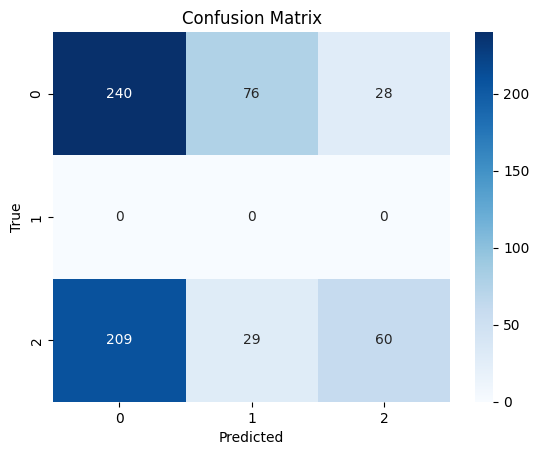


 Classification Report:
              precision    recall  f1-score   support

           0      0.535     0.698     0.605       344
           1      0.000     0.000     0.000         0
           2      0.682     0.201     0.311       298

    accuracy                          0.467       642
   macro avg      0.405     0.300     0.305       642
weighted avg      0.603     0.467     0.469       642



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# test_loader should yield: (image_seq, metadata_seq, labels)
preds, labels = test_model(model, test_loader5, device)

In [ ]:
# Save the trained model
model_save_path = "/content/drive/MyDrive/Thesis/POM-IMG/convnext_SEP_LSTM_LDA_on_CNN.pth"
torch.save(model.state_dict(), model_save_path)
print(f" Model saved to {model_save_path}")

 Model saved to /content/drive/MyDrive/Thesis/POM-IMG/convnext_SEP_LSTM_LDA_on_CNN.pth


In [ ]:
# Load models (metadata-only models now)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

row3_model = PomRowModel(num_metadata_features=3).to(device)
row4_model = PomRowModel(num_metadata_features=3).to(device)

# Load model weights
row3_model.load_state_dict(torch.load("/content/drive/MyDrive/Thesis/POM-IMG/com5_convnext_atten_LADF_on_CNN_16batch_30epochs_GCLH/convnext_SEP_LSTM_LDA_on_CNN.pth", map_location=device))
row4_model.load_state_dict(torch.load("/content/drive/MyDrive/Thesis/POM-IMG/com5_convnext_atten_LADF_on_CNN_16batch_30epochs_GCLH/convnext_SEP_LSTM_LDA_on_CNN.pth", map_location=device))

row3_model.eval()
row4_model.eval()

# Set test folder path and load folder names (adjust directory if needed)
test_row3_dir = "/content/drive/MyDrive/Thesis/POM-IMG/train_row3_SEF_LDA_CNN2"
folder_names = sorted([
    f for f in os.listdir(test_row3_dir)
    if os.path.isdir(os.path.join(test_row3_dir, f))
])

# MAIN LOOP
agree_and_correct = 0
total_samples = 0
disagreements = []
all_preds = []

for batch_row3, batch_row4 in tqdm(zip(test_loader3, test_loader4), total=len(test_loader3)):
    meta_r3, labels_r3 = batch_row3
    meta_r4, labels_r4 = batch_row4

    meta_r3 = meta_r3.to(device)
    meta_r4 = meta_r4.to(device)
    labels = labels_r3.to(device)

    with torch.no_grad():
        preds_r3 = row3_model(meta_r3).argmax(dim=1)
        preds_r4 = row4_model(meta_r4).argmax(dim=1)

    min_batch_size = min(len(preds_r3), len(preds_r4))

    for i in range(min_batch_size):
        pred3 = preds_r3[i].item()
        pred4 = preds_r4[i].item()
        label = labels[i].item()
        folder = folder_names[total_samples]  # Match folder name to sample

        if pred3 == pred4 and pred3 == label:
            agree_and_correct += 1
        elif pred3 != pred4:
            disagreements.append((folder, pred3, pred4, label))

        all_preds.append((folder, pred3, pred4, label))
        total_samples += 1

# Report results
accuracy = agree_and_correct / total_samples
print(f"\n Agreement Accuracy: {accuracy:.4f}")
print(f" Disagreements: {len(disagreements)} / {total_samples}")

# Save to CSV
results_df = pd.DataFrame(all_preds, columns=["Folder", "Row3_Pred", "Row4_Pred", "True_Label"])
results_df.to_csv("/content/drive/MyDrive/Thesis/POM-IMG/model_comparison_results.csv", index=False)
print("Saved: model_comparison_results.csv")


100%|██████████| 21/21 [00:05<00:00,  3.72it/s]


 Agreement Accuracy: 0.2181
 Disagreements: 182 / 321
Saved: model_comparison_results.csv
